# Learning to Attack and Defend
## Phase 1 — Foundation + Probabilistic Attack Engine

**Pipeline:**  
`Synthetic Data → Tokenization → Baseline Transformer → MCMC Attack Engine → Adversarial Sequences + Drift Analysis`

**Covers Gantt Tasks 2–10.**  
No adversarial training / defense — that is Phase 2.

---

```
┌─────────────────────────────────────────────────────────────────────────┐
│                         PHASE 1 PIPELINE                                │
│                                                                         │
│  [Synthetic Dataset]                                                    │
│       │                                                                 │
│       ▼                                                                 │
│  [SMILES Tokenizer / Encoder]                                           │
│       │                                                                 │
│       ├──────────────────────┐                                          │
│       ▼                      ▼                                          │
│  [Baseline Transformer]  [Transition Model (Bigrams)]                   │
│  Property Predictor ŷ        │                                          │
│       │                      ▼                                          │
│       │              [MCMC Sampler]                                     │
│       │              Metropolis-Hastings                                │
│       │              Maximise |ŷ_adv − ŷ_orig|                         │
│       │                      │                                          │
│       │              [Plausibility Checker]                             │
│       │              Rule-based validity gate                           │
│       │                      │                                          │
│       ▼                      ▼                                          │
│  [Attack Evaluation: Drift Distribution + Results Table]               │
└─────────────────────────────────────────────────────────────────────────┘
```

## 0. Setup & Imports

In [1]:
# Install dependencies if running in a fresh Colab / venv
# Uncomment the line below if needed:
# !pip install torch numpy matplotlib pandas --quiet

import os, sys

# Ensure the project root is on the path so 'phase1' package is importable
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import torch
import matplotlib
matplotlib.use("Agg")   # headless-safe; change to "inline" for Jupyter display
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Phase 1 modules
from phase1.utils import (
    set_seed, ensure_dirs, plot_loss_curve, plot_drift_distribution,
    plot_transition_heatmap, plot_token_distribution,
    format_results_table, regression_report
)
from phase1.data import load_or_generate, dataset_stats
from phase1.representation import (
    build_default_tokenizer, CHEMISTRY_TOKENS, make_padding_mask
)
from phase1.model import (
    MaterialDataset, build_model, train, evaluate, load_model
)
from phase1.attack_engine import (
    TransitionModel, PlausibilityChecker, MCMCSampler,
    summarise_attack_results, results_to_records
)
from torch.utils.data import DataLoader

# ── Global config ─────────────────────────────────────────────────────────
SEED         = 42
N_SYNTHETIC  = 2000      # synthetic dataset size
N_EPOCHS     = 30        # baseline training epochs
BATCH_SIZE   = 32
LEARNING_RATE = 3e-4
MCMC_STEPS   = 50        # MCMC steps per adversarial sequence
MCMC_BETA    = 2.0       # temperature
MAX_MUTATIONS = 5        # max token substitutions per adversarial example
DRIFT_THRESHOLD = 0.30   # threshold for calling an attack 'successful'
N_ATTACK_SEQUENCES = 100 # how many test sequences to attack in the full run
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT   = "../checkpoints/baseline.pt"
OUTPUTS_DIR  = "../outputs"

set_seed(SEED)
ensure_dirs(OUTPUTS_DIR, "../checkpoints")

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"Seed     : {SEED}")

PyTorch  : 2.11.0+cpu
Device   : cpu
Seed     : 42


## 1. Dataset — Synthetic SMILES + Regression Property

No real dataset is provided → synthetic mode.  
Each sample is a SMILES-like token sequence with a synthetic regression target derived from atom composition + Gaussian noise.

In [2]:
splits = load_or_generate(
    csv_path    = None,      # ← set a CSV path here to switch to real data
    n_synthetic = N_SYNTHETIC,
    seed        = SEED,
)

train_smi,  train_prop  = splits["train"]
val_smi,    val_prop    = splits["val"]
test_smi,   test_prop   = splits["test"]

print(f"\nTrain / Val / Test sizes: {len(train_smi)} / {len(val_smi)} / {len(test_smi)}")

# Show 5 sample rows
print("\nSample training examples:")
print(f"{'SMILES':<30}  {'Property':>10}")
print("-" * 44)
for smi, prop in zip(train_smi[:5], train_prop[:5]):
    print(f"{smi:<30}  {prop:>10.4f}")

[DATA MODE] -- SYNTHETIC --
  Generating 2000 synthetic SMILES-like sequences (seed=42)
  Generated 2000 unique sequences in 2000 attempts.
[Clean] Before cleaning: 2000 samples
[Clean] After cleaning:  2000 samples (removed 0)

-- Dataset Statistics ----------------------------------
  n_samples       : 2000
  len_mean        : 17.2515
  len_min         : 4
  len_max         : 38
  prop_mean       : 2.9440
  prop_std        : 1.1942
  prop_min        : 0.5437
  prop_max        : 6.4102
--------------------------------------------------------

[Split] train:  1400 samples  | property range [0.544, 6.166]  | mean 2.991
[Split] val  :   300 samples  | property range [0.589, 6.342]  | mean 2.894
[Split] test :   300 samples  | property range [0.552, 6.410]  | mean 2.775

Train / Val / Test sizes: 1400 / 300 / 300

Sample training examples:
SMILES                            Property
--------------------------------------------
FC-ONF5FO5-CS#N                     2.7539
ClNCFo              

## 2. Sequence Representation — Tokenizer & Encoder

Vocabulary(size=47, pad=0, unk=1, bos=2, eos=3)

All tokens (47): ['<PAD>', '<UNK>', '<BOS>', '<EOS>', 'Cl', 'Br', 'Si', 'Se', 'Na', 'Ca', 'Al', 'Mg', 'C', 'N', 'O', 'S', 'F', 'P', 'B', 'I', 'c', 'n', 'o', 's', 'p', '=', '#', '-', ':', '.', '(', ')', '[', ']', '+', '1', '2', '3', '4', '5', '6', '7', '8', 'H', '@', '/', '\\']

── Tokenisation Examples ───────────────────────────────────────────
  Input   : CCO
  Tokens  : ['<BOS>', 'C', 'C', 'O', '<EOS>']
  IDs     : [2, 12, 12, 14, 3]
  Decoded : CCO

  Input   : CC(=O)N
  Tokens  : ['<BOS>', 'C', 'C', '(', '=', 'O', ')', 'N', '<EOS>']
  IDs     : [2, 12, 12, 30, 25, 14, 31, 13, 3]
  Decoded : CC(=O)N

  Input   : C1CCCCC1
  Tokens  : ['<BOS>', 'C', '1', 'C', 'C', 'C', 'C', 'C', '1', '<EOS>']
  IDs     : [2, 12, 35, 12, 12, 12, 12, 12, 35, 3]
  Decoded : C1CCCCC1

  Input   : ClCCBr
  Tokens  : ['<BOS>', 'Cl', 'C', 'C', 'Br', '<EOS>']
  IDs     : [2, 4, 12, 12, 5, 3]
  Decoded : ClCCBr



[Plot] Token distribution saved → ../outputs/token_distribution.png


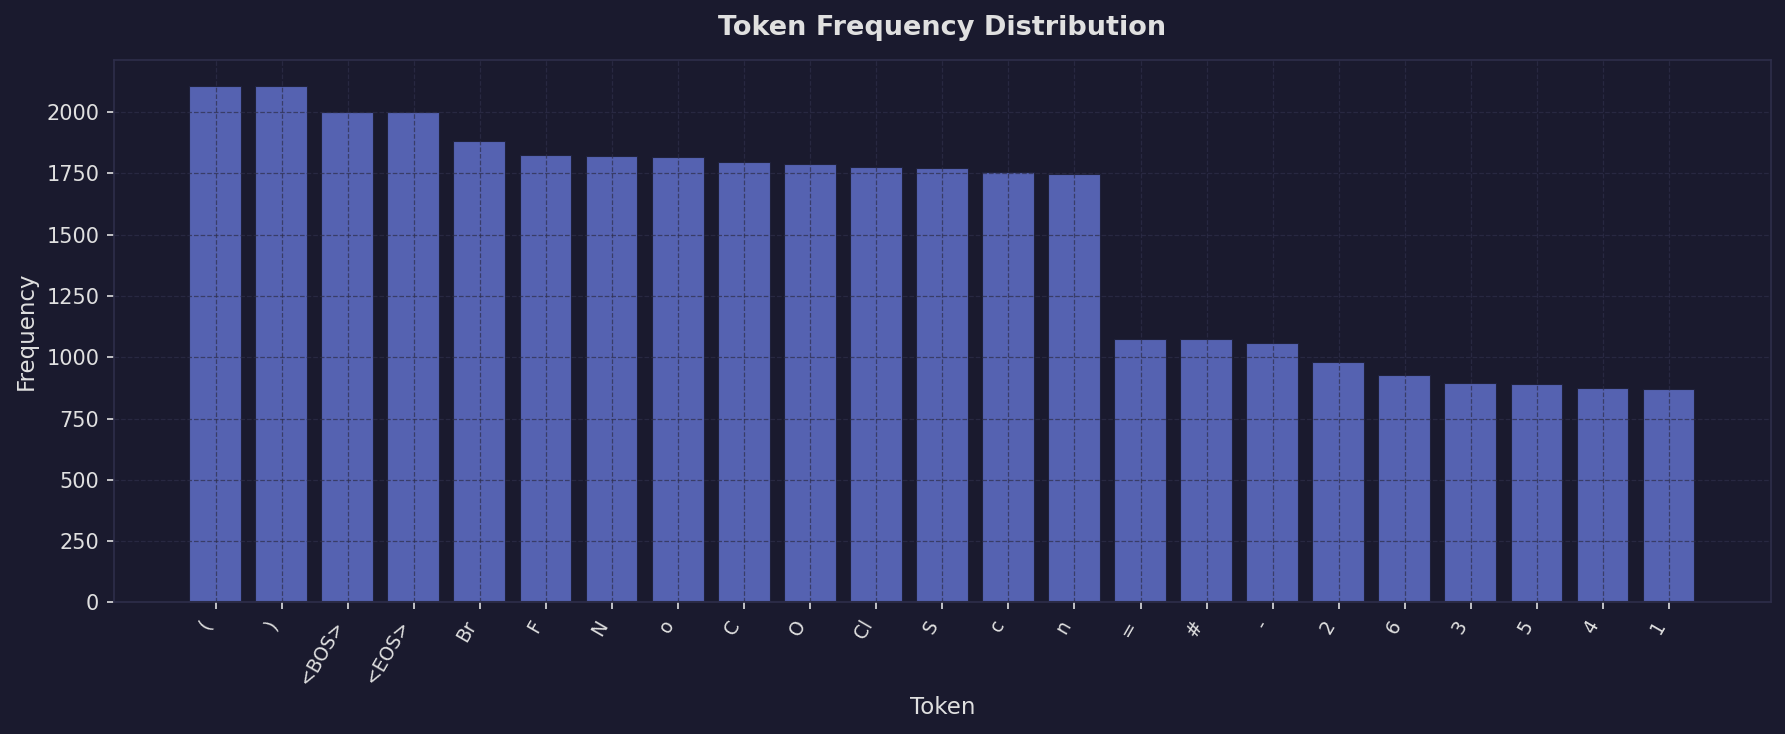

In [3]:
tokenizer = build_default_tokenizer(add_special=True)
vocab     = tokenizer.vocab

print(repr(vocab))
print(f"\nAll tokens ({vocab.size}): {vocab._tokens}")

# Demonstrate tokenisation
demo_smiles = [
    "CCO",
    "CC(=O)N",
    "C1CCCCC1",
    "ClCCBr",
]
print("\n── Tokenisation Examples ───────────────────────────────────────────")
for smi in demo_smiles:
    tokens = tokenizer.tokenize(smi)
    ids    = tokenizer.encode(smi)
    recon  = tokenizer.decode(ids)
    print(f"  Input   : {smi}")
    print(f"  Tokens  : {tokens}")
    print(f"  IDs     : {ids}")
    print(f"  Decoded : {recon}")
    print()

# Token frequency distribution
all_smi  = train_smi + val_smi + test_smi
tok_cnts = tokenizer.token_counts(all_smi)

plot_path = plot_token_distribution(
    tok_cnts,
    save_path = f"{OUTPUTS_DIR}/token_distribution.png",
    top_k     = 30,
)
display(Image(plot_path))

In [4]:
# Build padded batch tensors (used for all DataLoaders)
def make_loader(smi_list, prop_list, batch_size=BATCH_SIZE, shuffle=True, max_len=None):
    ids_arr, lengths = tokenizer.encode_batch(smi_list, max_len=max_len)
    props_arr = np.array(prop_list, dtype=np.float32)
    ds = MaterialDataset(ids_arr, lengths, props_arr)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

# Infer max_len from training set so val/test are consistent
train_ids, train_lengths = tokenizer.encode_batch(train_smi)
MAX_SEQ_LEN = train_ids.shape[1]
print(f"Max sequence length (after padding): {MAX_SEQ_LEN}")

train_loader = make_loader(train_smi, train_prop, max_len=MAX_SEQ_LEN)
val_loader   = make_loader(val_smi,   val_prop,   max_len=MAX_SEQ_LEN, shuffle=False)
test_loader  = make_loader(test_smi,  test_prop,  max_len=MAX_SEQ_LEN, shuffle=False)

print(f"Train batches: {len(train_loader)}  "
      f"Val batches: {len(val_loader)}  "
      f"Test batches: {len(test_loader)}")

Max sequence length (after padding): 38
Train batches: 44  Val batches: 10  Test batches: 10


## 3. Baseline Model — Transformer Encoder + Regression Head

Architecture: `Embedding → Positional Encoding → 2× TransformerEncoderLayer (d=64, 4 heads) → Mean Pooling → Linear Regression Head`

In [5]:
model = build_model(
    vocab_size = vocab.size,
    d_model    = 64,
    n_heads    = 4,
    n_layers   = 2,
    d_ff       = 128,
    dropout    = 0.10,
    max_len    = MAX_SEQ_LEN + 10,
    pad_id     = vocab.pad_id,
    device     = DEVICE,
)

print(f"\nModel summary: {model.n_params:,} trainable parameters")

[Model] TransformerPropertyPredictor
        vocab_size=47, d_model=64, n_heads=4, n_layers=2, d_ff=128
        Trainable parameters: 78,401
        Device: cpu

Model summary: 78,401 trainable parameters


In [6]:
print("Starting training …")

history = train(
    model,
    train_loader,
    val_loader,
    n_epochs        = N_EPOCHS,
    lr              = LEARNING_RATE,
    weight_decay    = 1e-4,
    patience        = 8,
    checkpoint_path = CHECKPOINT,
    device          = DEVICE,
    verbose         = True,
)

print(f"\nTraining complete. Best epoch: {history['best_epoch']}  "
      f"Best val loss: {history['best_val_loss']:.4f}")

Starting training …


  Epoch   1/30  train_loss=3.9821  val_loss=1.3116  MAE=0.9567  RMSE=1.1453  lr=2.99e-04  [1.3s]


  Epoch   5/30  train_loss=0.2929  val_loss=0.1343  MAE=0.2796  RMSE=0.3665  lr=2.81e-04  [7.1s]


  Epoch  10/30  train_loss=0.1685  val_loss=0.0533  MAE=0.1807  RMSE=0.2308  lr=2.29e-04  [13.4s]


  Epoch  15/30  train_loss=0.1367  val_loss=0.0487  MAE=0.1812  RMSE=0.2206  lr=1.58e-04  [19.1s]


  [Early stop] No improvement for 8 epochs. Best val loss = 0.0471 at epoch 11.

[Train] Finished. Best epoch=11  best_val_loss=0.0471  total_time=23.5s
[Train] Checkpoint saved → ../checkpoints/baseline.pt

Training complete. Best epoch: 11  Best val loss: 0.0471


[Plot] Loss curve saved → ../outputs/loss_curve.png


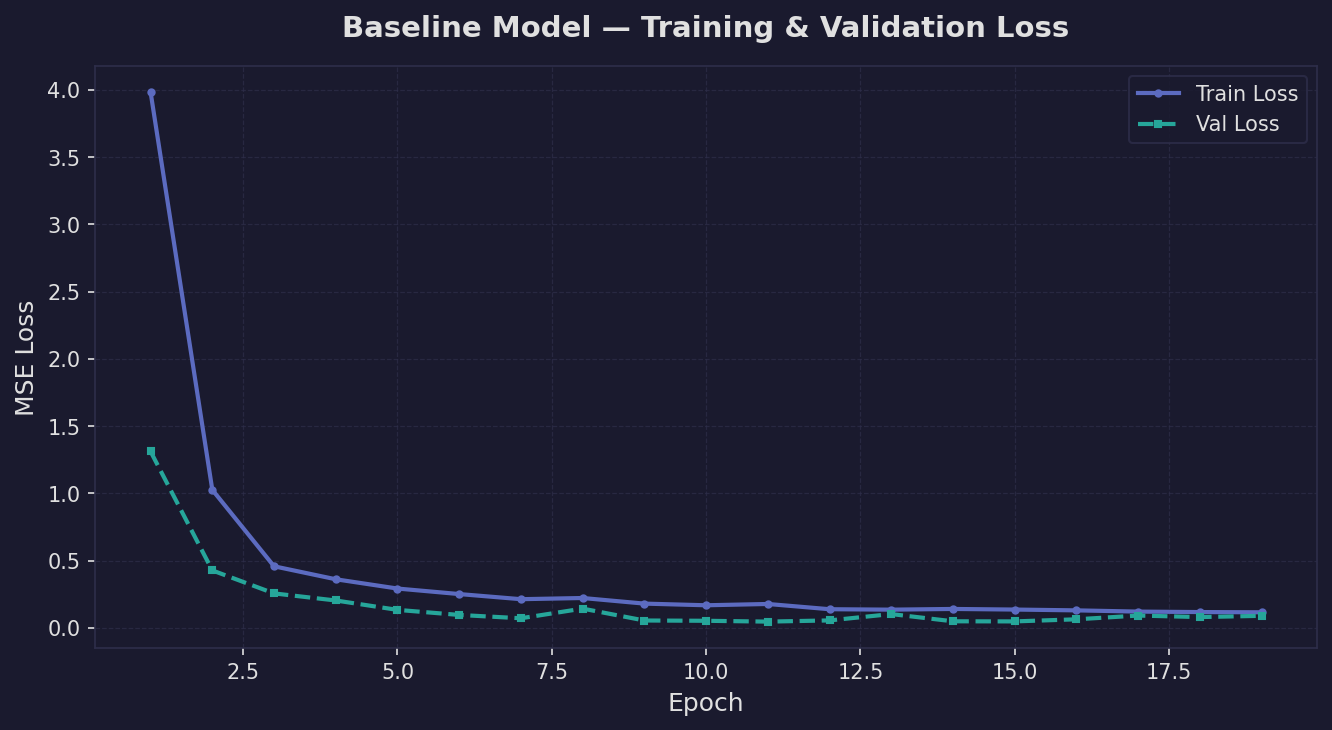

In [7]:
# Plot loss curve
lc_path = plot_loss_curve(
    history["train_losses"],
    history["val_losses"],
    save_path = f"{OUTPUTS_DIR}/loss_curve.png",
)
display(Image(lc_path))

In [8]:
# Load best checkpoint and evaluate on test set
best_model = load_model(CHECKPOINT, device=DEVICE)

_, y_true_test, y_pred_test = evaluate(best_model, test_loader, device=DEVICE)
test_metrics = regression_report(y_true_test, y_pred_test, split_name="test")

print(f"\nTest MAE  : {test_metrics['mae']:.4f}")
print(f"Test RMSE : {test_metrics['rmse']:.4f}")
print(f"Test R²   : {test_metrics['r2']:.4f}")

[Model] Loaded from ../checkpoints/baseline.pt (epoch 11, val_loss=0.0471, max_len=48)


[Metrics | test]  MAE=0.1891  RMSE=0.2419  R²=0.9614

Test MAE  : 0.1891
Test RMSE : 0.2419
Test R²   : 0.9614


## 4. Attack Engine — Transition Model (Bigrams)

In [9]:
# Encode training corpus
print("Fitting transition model on training corpus …")
train_encoded = [tokenizer.encode(s) for s in train_smi]

transition_model = TransitionModel(
    vocab_size  = vocab.size,
    token_list  = vocab._tokens,
    alpha       = 0.5,        # Laplace smoothing
)
transition_model.fit(train_encoded)

# Save matrix
tm_path = f"{OUTPUTS_DIR}/transition_matrix.npy"
transition_model.save(tm_path)

# Show top-5 replacements for common tokens
print("\n── Top-5 Probable Replacements by Token ─────────────────────────")
for tok_str in ["C", "N", "O", "S", "=", "("]:
    tid  = vocab.encode_token(tok_str)
    top5 = transition_model.top_k_replacements(tid, k=5)
    top5_str = ", ".join(f"'{t}' ({p:.3f})" for t, p in top5)
    print(f"  '{tok_str}' → {top5_str}")

Fitting transition model on training corpus …
[TransitionModel] Fitted on 1400 sequences, ~23,242 bigrams. Matrix: (47, 47), alpha=0.5
[TransitionModel] Matrix saved → ../outputs/transition_matrix.npy

── Top-5 Probable Replacements by Token ─────────────────────────
  'C' → ')' (0.084), '(' (0.062), 'N' (0.058), 'F' (0.052), '<EOS>' (0.051)
  'N' → ')' (0.084), 'N' (0.058), '(' (0.052), 'o' (0.051), 'Br' (0.049)
  'O' → ')' (0.089), '(' (0.064), '-' (0.054), 'Br' (0.052), 'S' (0.051)
  'S' → ')' (0.100), '(' (0.059), '<EOS>' (0.053), 'N' (0.051), 'n' (0.050)
  '=' → '(' (0.114), 'o' (0.095), 'Br' (0.095), 'c' (0.092), 'C' (0.090)
  '(' → 'N' (0.112), 'F' (0.110), 'Cl' (0.106), 'S' (0.102), 'Br' (0.102)


[Plot] Transition heatmap saved → ../outputs/transition_heatmap.png


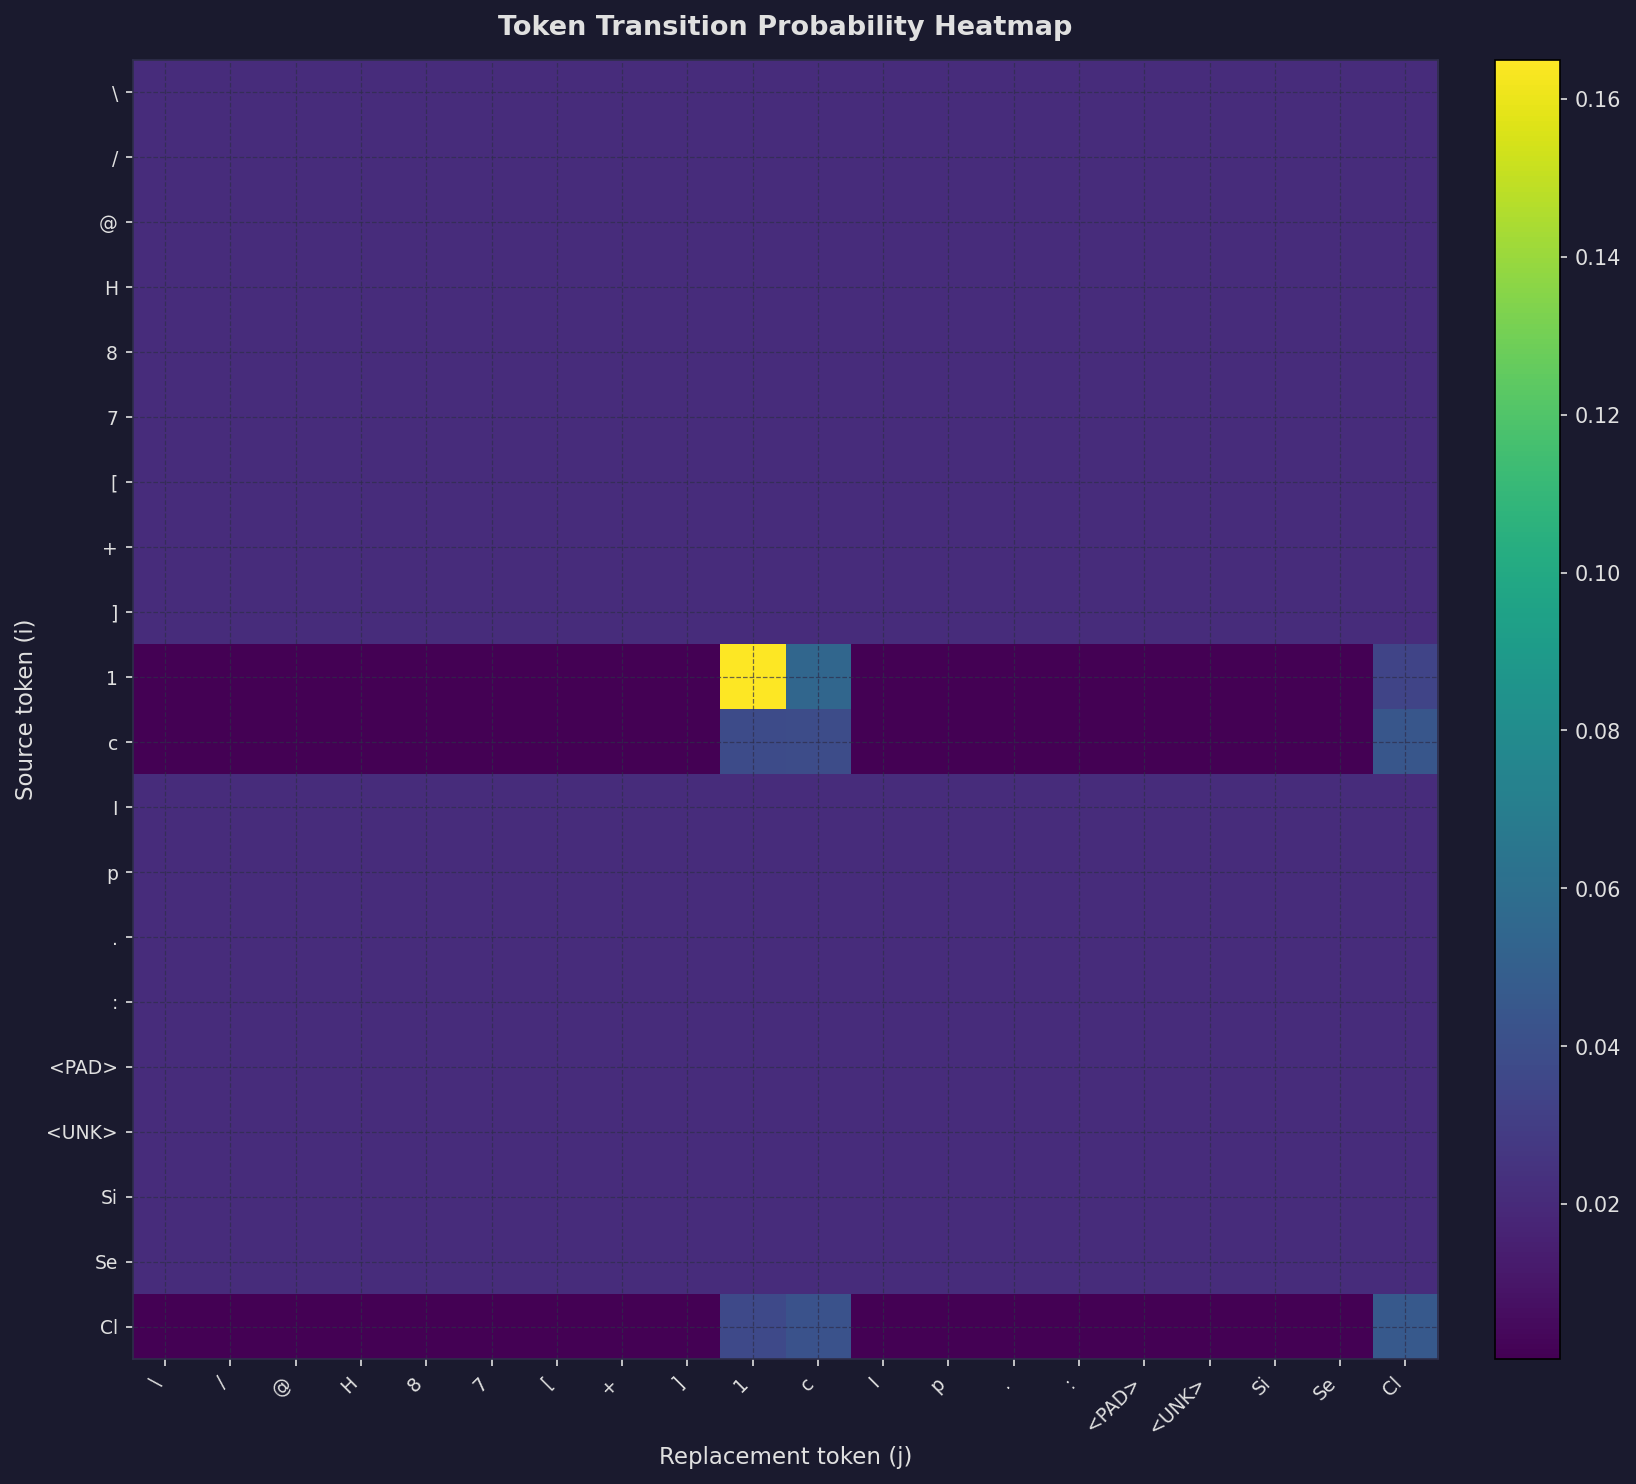

In [10]:
# Visualise transition heatmap (top-20 tokens)
heatmap_path = plot_transition_heatmap(
    transition_model.matrix,
    tokens    = vocab._tokens,
    save_path = f"{OUTPUTS_DIR}/transition_heatmap.png",
    top_k     = 20,
)
display(Image(heatmap_path))

## 5. Attack Engine — MCMC Sampler: Step-by-Step Demo

In [11]:
# Build plausibility checker
allowed_tokens = set(CHEMISTRY_TOKENS)
plausibility_checker = PlausibilityChecker(
    allowed_tokens = allowed_tokens,
    min_length     = 4,
    max_repeat     = 3,
)

# Build prediction function using the best checkpoint
best_model.eval()
best_model = best_model.to(DEVICE)

def predict_fn(smiles: str) -> float:
    """
    Single-sequence prediction using the loaded baseline model.
    Returns a float (the predicted property value).
    """
    ids_arr, lengths = tokenizer.encode_batch([smiles])
    ids_t = torch.from_numpy(ids_arr).long().to(DEVICE)
    with torch.no_grad():
        pred = best_model(ids_t)
    return float(pred.cpu().item())

# Build the MCMC sampler
mcmc_sampler = MCMCSampler(
    transition_model      = transition_model,
    plausibility_checker  = plausibility_checker,
    tokenizer             = tokenizer,
    predict_fn            = predict_fn,
    beta                  = MCMC_BETA,
    n_steps               = MCMC_STEPS,
    max_mutations         = MAX_MUTATIONS,
    seed                  = SEED,
)

print("MCMC Sampler ready.")
print(f"  β={MCMC_BETA}, n_steps={MCMC_STEPS}, max_mutations={MAX_MUTATIONS}")

MCMC Sampler ready.
  β=2.0, n_steps=50, max_mutations=5


In [12]:
# Step-by-step MCMC chain demo on 5 sequences
DEMO_SEQUENCES = test_smi[:5]

print("── MCMC Attack: Step-by-step on 5 test sequences ──────────────────\n")
demo_results = []
for i, smi in enumerate(DEMO_SEQUENCES):
    result = mcmc_sampler.attack(smi)
    demo_results.append(result)
    print(f"Sequence {i+1}: {smi}")
    print(f"  Original prediction : {result.original_pred:.4f}")
    print(f"  Adversarial         : {result.adversarial_smiles}")
    print(f"  Adversarial pred    : {result.adversarial_pred:.4f}")
    print(f"  Drift               : {result.drift:.4f}")
    print(f"  Mutations           : {result.n_mutations}")
    print(f"  Accepted / total    : {result.n_accepted} / {result.n_steps}")
    print(f"  Plausible           : {result.is_valid} ({result.validity_reason})")
    print(f"  Chain drift history : {[f'{d:.3f}' for d in result.chain_drifts[:10]]} …")
    print()

── MCMC Attack: Step-by-step on 5 test sequences ──────────────────

Sequence 1: nc#F=C4(Br(Br3))43
  Original prediction : 2.4167
  Adversarial         : nC===C4(O(Br3))43
  Adversarial pred    : 1.8278
  Drift               : 0.5888
  Mutations           : 4
  Accepted / total    : 10 / 50
  Plausible           : True (OK)
  Chain drift history : ['0.000', '0.059', '0.016', '0.086', '0.067', '0.313', '0.290', '0.517', '0.509', '0.589'] …

Sequence 2: (Br)Clo(N)
  Original prediction : 1.4717
  Adversarial         : (N)oC(Cl)
  Adversarial pred    : 0.7294
  Drift               : 0.7423
  Mutations           : 4
  Accepted / total    : 13 / 50
  Plausible           : True (OK)
  Chain drift history : ['0.000', '0.064', '0.270', '0.372', '0.370', '0.355', '0.336', '0.291', '0.658', '0.511'] …

Sequence 3: O(O(nO)=oS)
  Original prediction : 1.5003
  Adversarial         : F(o(BrO)CloCl)
  Adversarial pred    : 2.5695
  Drift               : 1.0692
  Mutations           : 5
  Accepted / 

## 6. Full Attack Run — All Test Sequences

In [13]:
attack_targets = test_smi[:N_ATTACK_SEQUENCES]
print(f"Running MCMC attack on {len(attack_targets)} test sequences …")
print(f"(MCMC steps per sequence = {MCMC_STEPS}, β = {MCMC_BETA})\n")

all_results = mcmc_sampler.attack_batch(attack_targets, verbose=True)

Running MCMC attack on 100 test sequences …
(MCMC steps per sequence = 50, β = 2.0)

  Attacked 1/100  best_drift=0.9786  accepted=10/50  valid=True


  Attacked 11/100  best_drift=1.5503  accepted=11/50  valid=True


  Attacked 21/100  best_drift=0.8157  accepted=15/50  valid=True


  Attacked 31/100  best_drift=1.2712  accepted=10/50  valid=True


  Attacked 41/100  best_drift=0.8026  accepted=16/50  valid=True


...

  Attacked 61/100  best_drift=0.6386  accepted=15/50  valid=True


  Attacked 71/100  best_drift=0.6822  accepted=8/50  valid=True


  Attacked 81/100  best_drift=0.4721  accepted=12/50  valid=True


  Attacked 91/100  best_drift=0.2504  accepted=6/50  valid=True


  Attacked 100/100  best_drift=1.2642  accepted=17/50  valid=True


In [14]:
# Summary statistics
summary = summarise_attack_results(all_results, drift_threshold=DRIFT_THRESHOLD)


-- Attack Summary --------------------------------------------------------
  n_attacks                 : 100
  mean_drift                : 0.8682
  median_drift              : 0.8028
  max_drift                 : 2.0765
  std_drift                 : 0.3649
  attack_success_rate       : 97.0000%
  validity_rate             : 100.0000%
  mean_mutations            : 4.4400
  mean_accepted             : 13.2400
  drift_threshold           : 0.3000
--------------------------------------------------------------------------



In [15]:
# Results table — first 20 rows
records = results_to_records(all_results)

print("── Attack Results Table (first 20 rows) ────────────────────────────")
from phase1.utils import format_results_table
print(format_results_table(records[:20]))

── Attack Results Table (first 20 rows) ────────────────────────────
─────────────────────────────────────────────────────────────────────────────────────────────────────────────
│       Original       │     Adversarial      │ Orig Pred │ Adv Pred │ Drift │ Mutations │ Valid │ Accepted │
─────────────────────────────────────────────────────────────────────────────────────────────────────────────
│  nc#F=C4(Br(Br3))43  │   NcCC=C4(C(O3))43   │   2.417   │  1.438   │ 0.979 │     5     │   ✓   │  10/50   │
│      (Br)Clo(N)      │       (o)nc(c)       │   1.472   │  0.487   │ 0.985 │     4     │   ✓   │  15/50   │
│     O(O(nO)=oS)      │     O(O(-n)cOC)      │   1.500   │  1.039   │ 0.461 │     5     │   ✓   │  20/50   │
│   cno(ClBrBr)n5O5    │    cn=(F@Br)S5Br5    │   2.968   │  1.832   │ 1.137 │     5     │   ✓   │   9/50   │
│  oSo(BrBr)=cnSnCFo   │ oSo(BrBr)FClnSnOFBr  │   3.267   │  4.901   │ 1.634 │     4     │   ✓   │   8/50   │
│     c(Cl)(N)C11      │      C(c)(#)c11      │   0

## 7. Prediction Drift Distribution

[Plot] Drift distribution saved → ../outputs/drift_distribution.png

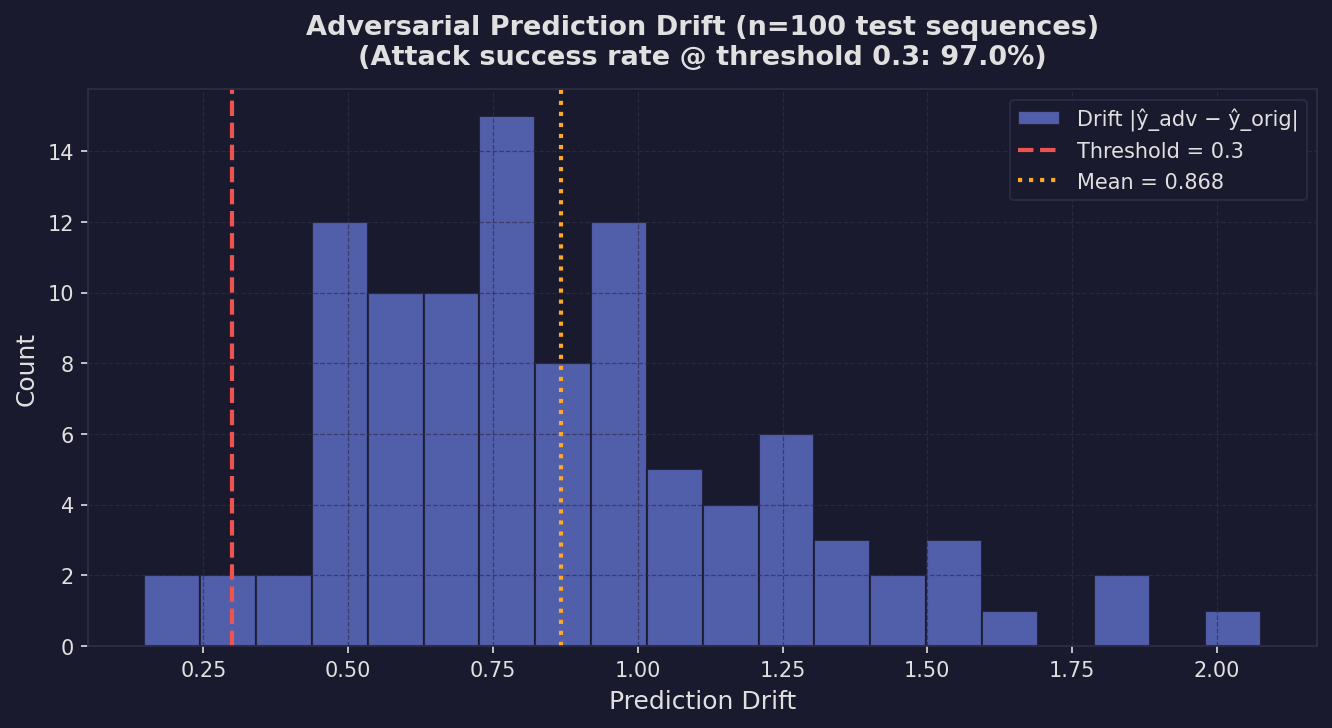


Drift statistics:
  Mean   : 0.8682
  Median : 0.8028
  Max    : 2.0765
  Std    : 0.3649
  Attack success (drift > 0.3): 97.0%


In [16]:
drifts = [r.drift for r in all_results]

drift_plot_path = plot_drift_distribution(
    drifts,
    save_path  = f"{OUTPUTS_DIR}/drift_distribution.png",
    threshold  = DRIFT_THRESHOLD,
    title      = f"Adversarial Prediction Drift (n={len(drifts)} test sequences)",
)
display(Image(drift_plot_path))

print(f"\nDrift statistics:")
print(f"  Mean   : {np.mean(drifts):.4f}")
print(f"  Median : {np.median(drifts):.4f}")
print(f"  Max    : {np.max(drifts):.4f}")
print(f"  Std    : {np.std(drifts):.4f}")
print(f"  Attack success (drift > {DRIFT_THRESHOLD}): "
      f"{100 * np.mean(np.array(drifts) > DRIFT_THRESHOLD):.1f}%")

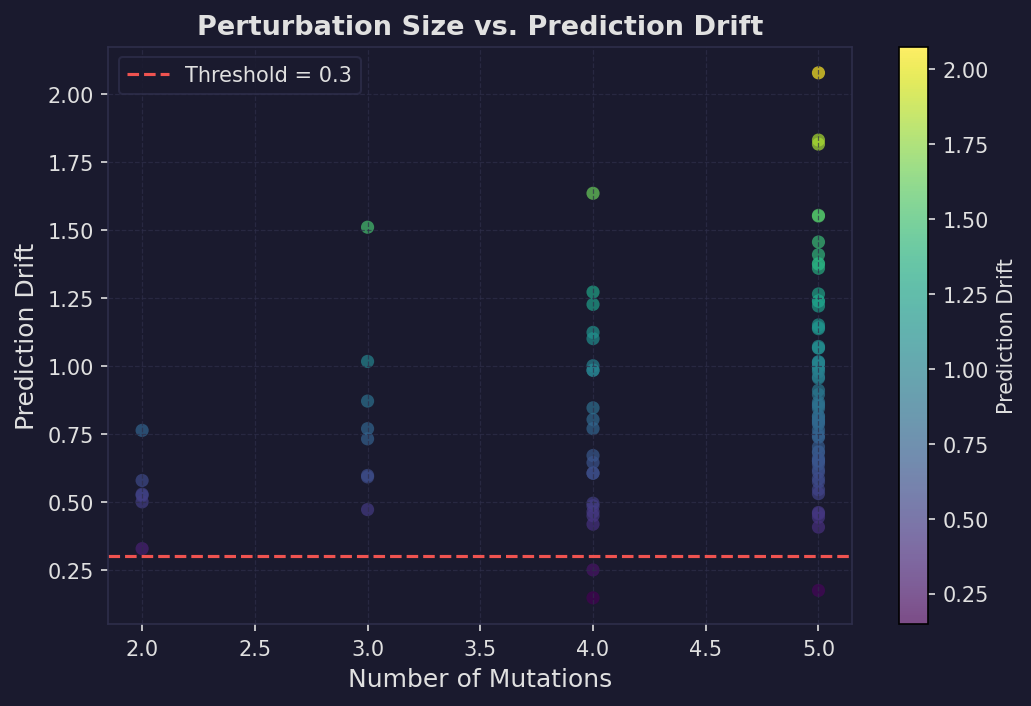

Saved → ../outputs/perturbation_vs_drift.png


In [17]:
# Additional plot: perturbation size vs. drift scatter
mutations = [r.n_mutations for r in all_results]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#1A1A2E")
ax.set_facecolor("#1A1A2E")

sc = ax.scatter(mutations, drifts,
                c=drifts, cmap="viridis",
                alpha=0.7, edgecolors="none", s=40)
cbar = plt.colorbar(sc, ax=ax)
cbar.ax.yaxis.set_tick_params(color="#E0E0E0")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#E0E0E0")
cbar.set_label("Prediction Drift", color="#E0E0E0")

ax.axhline(DRIFT_THRESHOLD, color="#EF5350", linewidth=1.5,
           linestyle="--", label=f"Threshold = {DRIFT_THRESHOLD}")
ax.set_xlabel("Number of Mutations", color="#E0E0E0", fontsize=12)
ax.set_ylabel("Prediction Drift",    color="#E0E0E0", fontsize=12)
ax.set_title("Perturbation Size vs. Prediction Drift",
             color="#E0E0E0", fontsize=13, fontweight="bold")
ax.tick_params(colors="#E0E0E0")
for sp in ax.spines.values():
    sp.set_color("#2E2E4A")
ax.grid(color="#2E2E4A", linestyle="--", linewidth=0.6, alpha=0.7)
ax.legend(facecolor="#1A1A2E", edgecolor="#2E2E4A", labelcolor="#E0E0E0")

scatter_path = f"{OUTPUTS_DIR}/perturbation_vs_drift.png"
fig.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(scatter_path))
print(f"Saved → {scatter_path}")

## 8. Phase 1 Summary — Baseline Model Fragility Analysis

*Auto-generated from experiment results.*

In [18]:
valid_attacks   = [r for r in all_results if r.is_valid]
invalid_attacks = [r for r in all_results if not r.is_valid]
successful      = [r for r in all_results if r.drift > DRIFT_THRESHOLD]

print("=" * 70)
print("PHASE 1 SUMMARY — Baseline Model Fragility Analysis")
print("=" * 70)
print()
print(f"Dataset          : SYNTHETIC (mode clearly stated above)")
print(f"Dataset size     : {len(train_smi)} train / {len(val_smi)} val / {len(test_smi)} test")
print(f"Baseline model   : Transformer encoder (d=64, 2 layers, 4 heads)")
print(f"Baseline test MAE: {test_metrics['mae']:.4f}")
print(f"Baseline test R² : {test_metrics['r2']:.4f}")
print()
print(f"Attack config    : MCMC Metropolis-Hastings, β={MCMC_BETA}, "
      f"{MCMC_STEPS} steps, max {MAX_MUTATIONS} mutations")
print(f"Sequences attacked: {len(all_results)}")
print(f"Valid adversarial : {len(valid_attacks)} ({100*len(valid_attacks)/len(all_results):.1f}%)")
print(f"Attack success   : {len(successful)} ({100*len(successful)/len(all_results):.1f}%) "
      f"at drift threshold = {DRIFT_THRESHOLD}")
print(f"Mean drift       : {np.mean(drifts):.4f}")
print(f"Max drift        : {np.max(drifts):.4f}")
print()
print("── Fragility Observations ──────────────────────────────────────────")
mean_drift   = np.mean(drifts)
success_rate = 100 * len(successful) / len(all_results)
validity_rate = 100 * len(valid_attacks) / len(all_results)
print(f"""
The baseline Transformer property predictor shows measurable fragility to
token-level adversarial perturbations generated by the probabilistic MCMC engine.
With an average prediction drift of {mean_drift:.3f} and an attack success rate of
{success_rate:.1f}% (drift > {DRIFT_THRESHOLD}) across {len(all_results)} test sequences, the model's
predictions can be shifted meaningfully by changing as few as 1–{MAX_MUTATIONS} tokens
in the input SMILES sequence — all while preserving {validity_rate:.1f}% plausibility as
measured by the rule-based validity checker.

The transition model constrains the search to statistically common token substitutions
observed in the training corpus, ensuring that adversarial sequences are not arbitrary
random strings but plausible SMILES-grammar-conforming candidates.  The right tail of
the drift distribution reveals a subset of highly vulnerable sequences where minimal
perturbation causes large property prediction changes — a clear target for the Phase 2
adversarial training defence.

Phase 2 will: (1) formally evaluate attack success/plausibility with a comparison to
random and rule-based baseline attackers, (2) retrain the model on augmented
adversarial data, and (3) verify robustness on a fresh unseen attack set.
""")
print("=" * 70)

PHASE 1 SUMMARY — Baseline Model Fragility Analysis

Dataset          : SYNTHETIC (mode clearly stated above)
Dataset size     : 1400 train / 300 val / 300 test
Baseline model   : Transformer encoder (d=64, 2 layers, 4 heads)
Baseline test MAE: 0.1891
Baseline test R² : 0.9614

Attack config    : MCMC Metropolis-Hastings, β=2.0, 50 steps, max 5 mutations
Sequences attacked: 100
Valid adversarial : 100 (100.0%)
Attack success   : 97 (97.0%) at drift threshold = 0.3
Mean drift       : 0.8682
Max drift        : 2.0765

── Fragility Observations ──────────────────────────────────────────

The baseline Transformer property predictor shows measurable fragility to
token-level adversarial perturbations generated by the probabilistic MCMC engine.
With an average prediction drift of 0.868 and an attack success rate of
97.0% (drift > 0.3) across 100 test sequences, the model's
predictions can be shifted meaningfully by changing as few as 1–5 tokens
in the input SMILES sequence — all while preserv

In [19]:
# Save results as JSON for Phase 2 consumption
import json

phase1_output = {
    "dataset_mode":    "synthetic",
    "n_train":         len(train_smi),
    "n_val":           len(val_smi),
    "n_test":          len(test_smi),
    "baseline_metrics": test_metrics,
    "attack_summary":   {
        "n_attacked":         len(all_results),
        "mean_drift":         float(np.mean(drifts)),
        "max_drift":          float(np.max(drifts)),
        "attack_success_pct": success_rate,
        "validity_pct":       validity_rate,
        "drift_threshold":    DRIFT_THRESHOLD,
        "mcmc_beta":          MCMC_BETA,
        "mcmc_steps":         MCMC_STEPS,
    },
    "adversarial_examples": [
        {
            "original":      r.original_smiles,
            "adversarial":   r.adversarial_smiles,
            "orig_pred":     r.original_pred,
            "adv_pred":      r.adversarial_pred,
            "drift":         r.drift,
            "n_mutations":   r.n_mutations,
            "is_valid":      r.is_valid,
        }
        for r in all_results
    ],
}

output_json_path = f"{OUTPUTS_DIR}/phase1_results.json"
with open(output_json_path, "w") as f:
    json.dump(phase1_output, f, indent=2)

print(f"Phase 1 results saved → {output_json_path}")
print("\n✓ Phase 1 complete. All deliverables generated:")
print(f"  [Checkpoint]  {os.path.abspath(CHECKPOINT)}")
print(f"  [Loss curve]  {OUTPUTS_DIR}/loss_curve.png")
print(f"  [Token dist.] {OUTPUTS_DIR}/token_distribution.png")
print(f"  [Trans. map]  {OUTPUTS_DIR}/transition_heatmap.png")
print(f"  [Drift dist.] {OUTPUTS_DIR}/drift_distribution.png")
print(f"  [Scatter]     {OUTPUTS_DIR}/perturbation_vs_drift.png")
print(f"  [Results JSON]{output_json_path}")

Phase 1 results saved → ../outputs/phase1_results.json

✓ Phase 1 complete. All deliverables generated:
  [Checkpoint]  C:\S5\DL\Project\checkpoints\baseline.pt
  [Loss curve]  ../outputs/loss_curve.png
  [Token dist.] ../outputs/token_distribution.png
  [Trans. map]  ../outputs/transition_heatmap.png
  [Drift dist.] ../outputs/drift_distribution.png
  [Scatter]     ../outputs/perturbation_vs_drift.png
  [Results JSON]../outputs/phase1_results.json
